Download from https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

In [1]:
import pandas as pd

df = pd.read_parquet("data/Yellow_Taxi_Trip_Data_Jan_2025.parquet")

In [2]:
print(df.shape)
df.head()


(3475226, 20)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,1,2025-01-01 00:18:38,2025-01-01 00:26:59,1.0,1.60,1.0,N,229,237,1,10.0,3.5,0.5,3.00,0.0,1.0,18.00,2.5,0.0,0.0
1,1,2025-01-01 00:32:40,2025-01-01 00:35:13,1.0,0.50,1.0,N,236,237,1,5.1,3.5,0.5,2.02,0.0,1.0,12.12,2.5,0.0,0.0
2,1,2025-01-01 00:44:04,2025-01-01 00:46:01,1.0,0.60,1.0,N,141,141,1,5.1,3.5,0.5,2.00,0.0,1.0,12.10,2.5,0.0,0.0
3,2,2025-01-01 00:14:27,2025-01-01 00:20:01,3.0,0.52,1.0,N,244,244,2,7.2,1.0,0.5,0.00,0.0,1.0,9.70,0.0,0.0,0.0
4,2,2025-01-01 00:21:34,2025-01-01 00:25:06,3.0,0.66,1.0,N,244,116,2,5.8,1.0,0.5,0.00,0.0,1.0,8.30,0.0,0.0,0.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3475226 entries, 0 to 3475225
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee           

In [4]:
df.columns


Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'Airport_fee',
       'cbd_congestion_fee'],
      dtype='object')

In [5]:
import geopandas as gpd

# Load taxi zones shapefile (or geojson)
zones = gpd.read_file("data/Taxi_Zones/taxi_zones.shp")
zones.head()


,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


In [6]:
# Merge trip data with zones (pickup)
pickup = df.groupby("PULocationID").size().reset_index(name="count")
pickup = pickup.merge(zones, left_on="PULocationID", right_on="LocationID")

# Turn into GeoDataFrame
pickup_gdf = gpd.GeoDataFrame(pickup, geometry="geometry", crs=zones.crs)


pickup_gdf["centroid"] = pickup_gdf.geometry.centroid

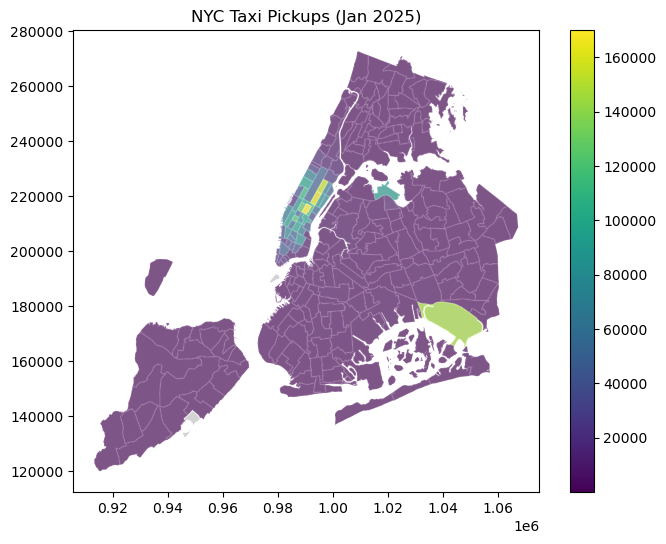

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))
zones.plot(ax=ax, color="lightgrey", edgecolor="white")  # basemap

pickup_gdf.plot(
    ax=ax,
    column="count",
    markersize=pickup_gdf["count"] / 500,  # adjust scaling
    cmap="viridis",
    alpha=0.6,
    legend=True,
)

plt.title("NYC Taxi Pickups (Jan 2025)")
plt.savefig("NYC_taxi_pickups_jan_2025_by_zone.pdf", dpi=300)
plt.show()


In [8]:
# get centroids
pickup_gdf["centroid"] = pickup_gdf.geometry.centroid
pickup_gdf["x"] = pickup_gdf.centroid.x
pickup_gdf["y"] = pickup_gdf.centroid.y

# point cloud (2D array)
X = pickup_gdf[["x", "y"]].to_numpy()

# function values (1D array)
f = pickup_gdf["count"].to_numpy()

print("Point cloud shape:", X.shape)  # (zones, 2)
print("Function values shape:", f.shape)  # (zones,)


Point cloud shape: (259, 2)
Function values shape: (259,)


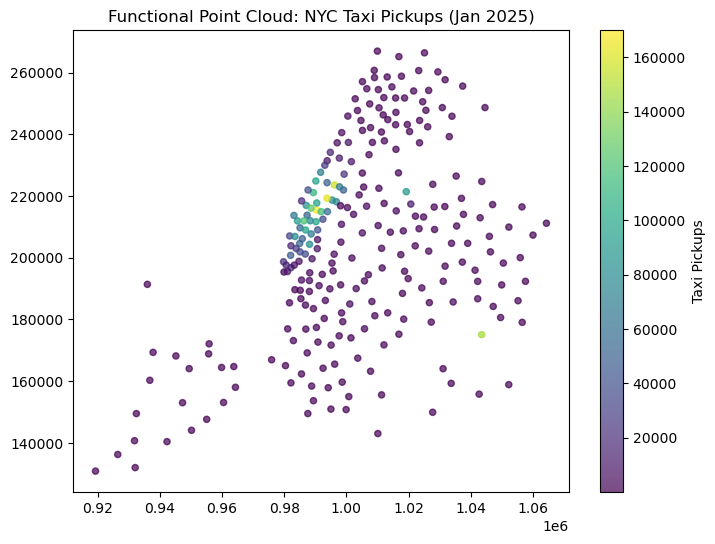

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=f, cmap="viridis", s=20, alpha=0.7)
plt.colorbar(label="Taxi Pickups")
plt.title("Functional Point Cloud: NYC Taxi Pickups (Jan 2025)")
plt.savefig("NYC_taxi_pickups_jan_2025_point_cloud.pdf", dpi=300)
plt.show()

In [11]:
import graph_mph
import numpy as np


def compute_approximated_Hilbert_matrix(
    res: dict[str, list[tuple[int, int]]],
    table_x_coords: list[float],
    table_y_coords: list[float],
    target_matrix_shape: tuple[int, int],
):
    # convert the graded betti numbers in indices to filtration values
    b_0_values = graph_mph.map_graded_betti_numbers_to_filtration_values(
        res["b_0"], table_x_coords, table_y_coords
    )
    b_0_values = np.array(b_0_values)
    b_1_values = graph_mph.map_graded_betti_numbers_to_filtration_values(
        res["b_1"], table_x_coords, table_y_coords
    )
    b_1_values = np.array(b_1_values)
    b_2_values = graph_mph.map_graded_betti_numbers_to_filtration_values(
        res["b_2"], table_x_coords, table_y_coords
    )
    b_2_values = np.array(b_2_values)

    target_m, target_n = target_matrix_shape
    xs = np.linspace(table_x_coords[0], table_x_coords[-1], target_m)
    ys = np.linspace(table_y_coords[0], table_y_coords[-1], target_n)
    matrix_meshgrid = np.meshgrid(xs, ys, indexing="ij")

    cumsum_b_0 = np.zeros((target_m, target_n), dtype=np.int32)
    cumsum_b_1 = np.zeros((target_m, target_n), dtype=np.int32)
    cumsum_b_2 = np.zeros((target_m, target_n), dtype=np.int32)
    for i in range(target_m):
        for j in range(target_n):
            s, k = matrix_meshgrid[0][i][j], matrix_meshgrid[1][i][j]
            # counts the number of rows (x,y) in b_0_values that satisfy x <= s and y <= k
            cumsum_b_0[i, j] = np.sum((b_0_values[:, 0] <= s) & (b_0_values[:, 1] <= k))
            cumsum_b_1[i, j] = np.sum((b_1_values[:, 0] <= s) & (b_1_values[:, 1] <= k))
            cumsum_b_2[i, j] = np.sum((b_2_values[:, 0] <= s) & (b_2_values[:, 1] <= k))

    return cumsum_b_0, cumsum_b_1, cumsum_b_2

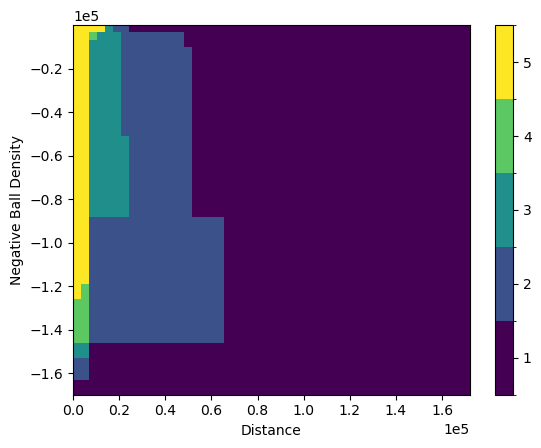

In [ ]:
import dis
import graph_mph

# build a bi-filtration from a functional point cloud
bifi = graph_mph.BiFiltration(
    points=X,
    function_values=-f,
)

graded_graph = bifi.ggraph
res = graph_mph.compute_MPH0(graded_graph)

table_x_coords = bifi.get_x_coords()
table_y_coords = bifi.get_y_coords()


# compute the approximated Hilbert matrix
cum_0, cum_1, cum_2 = compute_approximated_Hilbert_matrix(
    res, table_x_coords, table_y_coords, (50, 50)
)

approx_hilbert_matrix = cum_0 - cum_1 + cum_2
# map the value greater to 4 to 4
approx_hilbert_matrix = np.clip(approx_hilbert_matrix, 0, 5)
# matrix_to_plot = np.log(approx_hilbert_matrix + 1)
matrix_to_plot = approx_hilbert_matrix

# plot the approximated Hilbert matrix (distance vs ball density)
xrange = np.min(table_x_coords), np.max(table_x_coords)
yrange = np.min(table_y_coords), np.max(table_y_coords)
discrete_plot, cbar = graph_mph.draw_discrete_matrix(
    matrix_to_plot, x_axis_range=yrange, y_axis_range=xrange, origin="lower"
)
discrete_plot.set_figsize(8, 6)

# Format axes to use scientific notation
discrete_plot.ticklabel_format(style="scientific", axis="x", scilimits=(0, 0))
discrete_plot.ticklabel_format(style="scientific", axis="y", scilimits=(0, 0))

discrete_plot.xlabel("Distance")
discrete_plot.ylabel("Negative Ball Density")
discrete_plot.savefig("Hibert_matrix_ball_density_rips_NYC_taxi.pdf", dpi=300)
discrete_plot.show()

It shows that there are clearly two connected components and there is also a functional peak close to the main point cloud.